## Group Project Phase II
### Evaluating the Impact of ESG Practices on Stock Valuations

#### DS 3000 Mon, Wed 2:50p-4:30p
#### Name: Sahaj Baxi, Joshua Sharma, Beatriz Braz Auto Marinho, Hang Hang

### Introduction and Central Motivation
The project will explore how Environmental, Social, and Governance (ESG) scores affect a company's stock performance. ESG scores are increasingly becoming a factor for investors when selecting companies, and this project aims to analyze if there is a clear link between strong ESG performance and financial outcomes in the market. By analyzing the relationship between a company's ESG rating and its stock price volatility or returns, I want to answer the below two key questions:

- Do companies with higher ESG ratings experience lower stock price volatility?
- Is there a correlation between ESG scores and stock returns over time?

### Data Collection and processing pipeline
To source real time data for analysis, we plan to use Yahoo Finance API and Python Yahoo Finance libraries which allows us to request stock prices, fundamental data (market cap, P/E ratio, etc.), and ESG metrics for thousands of tickers in an automated way. we will focus on numeric features (e.g., stock price, market cap, ESG risk scores) and categorical feature (ESG risk level, company sector, industries (the latter two we haven't scraped them yet)). Data will be filtered to include companies with a range of ESG scores, providing both high and low ESG focus cases for comparison. 

Please see below the approach, we've had so far for extracting the data. To ensure sufficient sample size, we plan to pull the list of S&P 500 company (or it could be Fortune 1000 companies if we want more coverage) from Wikipedia as the list of tickers and pass them into my function (e.g. get_stock_data) for scraping data from Yahoo Finance.

In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import yfinance as yf
import yesg
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Retrieval and Cleaning

This sector is responsible for fetching raw data from external sources (slickcharts.com) for stock price and date and other financial metrics (i.e. Beta, PE Ratio, EPS for the last 12 months) from Python's Yahoo Finance library.

Functions:
- adjust_ticker(ticker): Adjusts specific tickers to ensure compatibility with Python Yahoo Finance library.
- get_sp500_data(num_tickers):
  - Scrapes S&P 500 tickers from the website and adjusts ticker formatting.
  - Downloads raw stock performance data using the yfinance API.
- get_financial_metrics(tickers): Retrieves financial metrics like Beta, PE Ratio, and EPS (TTM) from Python Yahoo Finance library.

In [2]:
# Adjust the 'BRK.B' ticker format for Yahoo Finance compatibility
def adjust_ticker(ticker):
    """
    Check if the input ticker is 'BRK.B' and replace it accordingly just to be compatible with Yahoo Finance.
    
    Args:
        ticker (str): The stock ticker symbol to adjust.

    Returns:
        str: The adjusted ticker symbol.
    """
    return ticker.replace('.', '-') if ticker == 'BRK.B' else ticker

def get_sp500_data(num_tickers=100):
    """
    Scrapes S&P 500 tickers from 'slickcharts.com', adjusts the format for Yahoo Finance, 
    and downloads the stock data for the specified number of tickers.
    
    Args:
        num_tickers (int): Number of tickers to download data for (default is 100).
    
    Returns:
        pd.DataFrame: A DataFrame containing stock data for the specified tickers.
        list: List of S&P 500 tickers adjusted for Yahoo Finance.
    """
    # Set up headers to mimic browser
    headers = {"User-Agent": ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                              '(KHTML, like Gecko) Chrome/94.0.4606.81 Safari/537.36')}
    
    # Scrape the S&P 500 tickers
    response = requests.get('https://www.slickcharts.com/sp500', headers=headers)
    tables = pd.read_html(response.text)
    # create a list of symbols (tickers)
    top500 = tables[0].Symbol.tolist()

    # Adjust the 'BRK.B' ticker format and format other tickers
    top500 = [adjust_ticker(ticker) for ticker in top500]
    
    # turn the list of tickers into a string with a separator of ,
    tickers_string = ','.join(top500[:num_tickers])

    # use yahoo finance API to bulk request data for a 1D period
    stock_data = yf.download(tickers_string, period='1d', group_by='ticker')

    return stock_data, top500[:num_tickers]

def get_financial_metrics(tickers):
    """
    Retrieves financial metrics (Beta, PE Ratio, EPS) from Python yfinance library for given tickers.

    Args:
        tickers (list): List of stock tickers to retrieve financial metrics for.

    Returns:
        pd.DataFrame: DataFrame containing financial metrics.
    """
    metrics_data = []
    
    for ticker in tickers:
        ticker_info = yf.Ticker(ticker).info
        
        beta = ticker_info.get('beta', 'N/A')
        pe_ratio = ticker_info.get('trailingPE', 'N/A')
        eps_ttm = ticker_info.get('trailingEps', 'N/A')
        
        metrics_data.append({
            'Ticker': ticker,
            'Beta': beta,
            'PE Ratio': pe_ratio,
            'EPS TTM': eps_ttm
        })
    
    return pd.DataFrame(metrics_data)

In [3]:
# Check the output df of get_sp500_data(num_tickers=100)
stock_data, top100 = get_sp500_data(num_tickers=100)
stock_data

[*********************100%***********************]  100 of 100 completed


Ticker                           NFLX                                 \
Price                            Open   High         Low       Close   
Date                                                                   
2024-10-25 00:00:00+00:00  756.169983  768.5  753.539978  754.679993   

Ticker                                                ANET              \
Price                       Adj Close   Volume        Open        High   
Date                                                                     
2024-10-25 00:00:00+00:00  754.679993  2768928  399.899994  400.769989   

Ticker                                             ...       GILD        \
Price                             Low       Close  ...        Low Close   
Date                                               ...                    
2024-10-25 00:00:00+00:00  393.401001  394.089996  ...  88.449997  89.0   

Ticker                                               TMO              \
Price                     Adj Close   Volume        Open        High   
Date                                                                   
2024-10-25 00:00:00+00:00      89.0  5683089  560.159973  562.219971   

Ticker                                                                 
Price                             Low       Close   Adj Close  Volume  
Date                                                                   
2024-10-25 00:00:00+00:00  553.305786  554.380005  554.380005  867346  

[1 rows x 600 columns]

In [4]:
# Check the output df of get_financial_metrics(tickers)
financials_df = get_financial_metrics(top100)
financials_df

,Ticker,Beta,PE Ratio,EPS TTM
0,AAPL,1.239,35.22222,6.57
1,NVDA,1.669,66.4507,2.13
2,MSFT,0.896,36.253174,11.81
3,AMZN,1.147,44.828163,4.19
4,META,1.216,29.352278,19.53
...,...,...,...,...
95,ANET,1.075,51.047928,7.72
96,UPS,0.979,21.306976,6.45
97,LRCX,1.481,25.13916,3.09
98,REGN,0.115,24.67654,37.81


## 2. More Data Cleaning and Data Processing
This sector focuses on refining the raw data obtained from the retrieval sector (i.e. the stock price, date, market cap), making it ready for analysis and extracting the ESG information from the Sustainability section of Yahoo Finance.
- clean_stocks: Clean the downloaded stock data by extracting the price, date, and market cap info.
- Func: get_esg_scores(tickers) which scrapes ESG info from Yahoo Finance for the given tickers.

In [5]:
def clean_stocks(stock_data):
    """
    Cleans the downloaded stock data by extracting the price, date, and market cap (billion).

    Args:
        stock_data (pd.DataFrame): Raw stock data retrieved using Yahoo Finance API through the 
        Python yfinance library.

    Returns:
        pd.DataFrame: Cleaned stock data with price, date, and market cap.
    """
    clean_stock_data = []
    for ticker in stock_data.columns.levels[0]:
        price = stock_data[ticker]['Close'].iloc[0]
        date = stock_data.iloc[0].name.strftime('%Y-%m-%d')

        shares = yf.Ticker(ticker).info.get('sharesOutstanding', None)
        
        if shares:
            market_cap = price * shares / 1e9
            market_cap = round(market_cap, 2) 
        else:
            market_cap = None
        
        clean_stock_data.append({
            'Ticker': ticker,
            'Price': price,
            'Date': date,
            'Market Cap (Billion)': market_cap
        })
    df_clean = pd.DataFrame(clean_stock_data)
    df_clean.set_index('Ticker', inplace=True)
    return df_clean


def get_esg_scores(tickers):
    """
    Scrapes ESG data from Yahoo Finance for the given tickers.

    Args:
        tickers (list): List of stock tickers to retrieve ESG data for.

    Returns:
        pd.DataFrame: DataFrame containing ESG scores and descriptions.
    """
    esg_scores = []
    
    for ticker in tickers:
        url = f'https://finance.yahoo.com/quote/{ticker}/sustainability/'
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        soup = BeautifulSoup(response.text, 'html.parser')
        # Extract total ESG score and its description (percentile and risk level)
        total_esg_section = soup.find('section', {'data-testid': 'TOTAL_ESG_SCORE'})

        # Extract total ESG score and description
        total_esg = total_esg_section.find('h4').text.strip() if total_esg_section else 'N/A'
        esg_description = (total_esg_section.find_all('span')[-1].text.strip()
                           if total_esg_section and total_esg_section.find_all('span') 
                           else 'N/A')
            
        # Extract environmental, social, and governance risk score
        env_section = soup.find('section', {'data-testid': 'ENVIRONMENTAL_SCORE'})
        env_risk = env_section.find('h4').text.strip() if env_section else 'N/A'

        social_section = soup.find('section', {'data-testid': 'SOCIAL_SCORE'})
        social_risk = social_section.find('h4').text.strip() if social_section else 'N/A'

        gov_section = soup.find('section', {'data-testid': 'GOVERNANCE_SCORE'})
        gov_risk = gov_section.find('h4').text.strip() if gov_section else 'N/A'
        
        esg_scores.append({
                'Ticker': ticker,
                'Total ESG Risk Score': total_esg,
                'ESG Description': esg_description,
                'Environmental Risk': env_risk,
                'Social Risk': social_risk,
                'Governance Risk': gov_risk})

    return pd.DataFrame(esg_scores)

In [6]:
# check the output
cleaned_stocks = clean_stocks(stock_data)
cleaned_stocks

,Price,Date,Market Cap (Billion)
Ticker,,,
AAPL,231.410004,2024-10-25,3518.38
ABBV,187.850006,2024-10-25,331.81
ABT,114.220001,2024-10-25,198.73
ACN,360.799988,2024-10-25,225.45
ADBE,483.720001,2024-10-25,212.93
...,...,...,...
VRTX,477.700012,2024-10-25,123.30
VZ,41.380001,2024-10-25,174.19
WFC,64.529999,2024-10-25,219.65


In [7]:
# check the output
esg_df = get_esg_scores(top100)
esg_df

,Ticker,Total ESG Risk Score,ESG Description,Environmental Risk,Social Risk,Governance Risk
0,AAPL,N/A,N/A,N/A,N/A,N/A
1,NVDA,N/A,N/A,N/A,N/A,N/A
2,MSFT,N/A,N/A,N/A,N/A,N/A
3,AMZN,N/A,N/A,N/A,N/A,N/A
4,META,N/A,N/A,N/A,N/A,N/A
...,...,...,...,...,...,...
95,ANET,N/A,N/A,N/A,N/A,N/A
96,UPS,N/A,N/A,N/A,N/A,N/A
97,LRCX,N/A,N/A,N/A,N/A,N/A
98,REGN,N/A,N/A,N/A,N/A,N/A


## 3. Data Integration & Consolidation

This sector merges different datasets to create a comprehensive view of each company's financial and ESG performance.

- Func: consolidate_dfs(tickers)

In [8]:
# Consolidate S&P500 tickers df and ESG scores df into a single df
def consolidate_dfs(tickers):
    """
    Consolidates stock data, ESG scores, and financial metrics into a single DataFrame.

    Args:
        tickers (list): List of stock tickers.

    Returns:
        pd.DataFrame: DataFrame containing consolidated data.
    """
    stock_df = clean_stocks(stock_data)
    esg_df = get_esg_scores(tickers)
    metrics_df = get_financial_metrics(tickers)

    # Merge the two dataframes on the 'Ticker' column
    consolidated_df = pd.merge(stock_df, esg_df, on='Ticker', how='left')
    consolidated_df = pd.merge(consolidated_df, metrics_df, on='Ticker', how='left')
    consolidated_df.fillna('N/A', inplace=True)
    return consolidated_df

consolidated_df = consolidate_dfs(top100)
consolidated_df

,Ticker,Price,Date,Market Cap (Billion),Total ESG Risk Score,ESG Description,Environmental Risk,Social Risk,Governance Risk,Beta,PE Ratio,EPS TTM
0,AAPL,231.410004,2024-10-25,3518.38,N/A,N/A,N/A,N/A,N/A,1.239,35.22222,6.57
1,ABBV,187.850006,2024-10-25,331.81,N/A,N/A,N/A,N/A,N/A,0.618,62.61667,3.00
2,ABT,114.220001,2024-10-25,198.73,N/A,N/A,N/A,N/A,N/A,0.722,34.717327,3.29
3,ACN,360.799988,2024-10-25,225.45,N/A,N/A,N/A,N/A,N/A,1.239,31.538462,11.44
4,ADBE,483.720001,2024-10-25,212.93,N/A,N/A,N/A,N/A,N/A,1.289,40.889263,11.83
...,...,...,...,...,...,...,...,...,...,...,...,...
95,VRTX,477.700012,2024-10-25,123.30,N/A,N/A,N/A,N/A,N/A,0.402,N/A,-1.98
96,VZ,41.380001,2024-10-25,174.19,N/A,N/A,N/A,N/A,N/A,0.411,17.913422,2.31
97,WFC,64.529999,2024-10-25,219.65,N/A,N/A,N/A,N/A,N/A,1.159,13.4158,4.81
98,WMT,82.510002,2024-10-25,663.24,N/A,N/A,N/A,N/A,N/A,0.516,42.97396,1.92


## Visulizations

### ESG vs Stock Price of Companies

In [11]:
# Filter out the ticker 'BKNG' to prevent skewing the overall visualization 
filtered_df = consolidated_df[consolidated_df['Ticker'] != 'BKNG']

# Creating a bubble plot with customized hover data
fig = px.scatter(filtered_df, 
                 x='Total ESG Risk Score', 
                 y='Price', 
                 size='Market Cap (Billion)',  # Bubble size based on Market Cap
                 color='ESG Description',     # Color by ESG Description
                 title='Total ESG Risk Score vs Price',
                 labels={'Total ESG Risk Score': 'Total ESG Risk Score', 'Price': 'Stock Price ($)'},
                 hover_data={
                     'Ticker': True,
                     'Price': ':.2f',            
                     'Total ESG Risk Score': True,
                     'Market Cap (Billion)': ':.1f', 
                     'Beta': ':.2f',             
                     'PE Ratio': ':.2f',        
                     'EPS TTM': ':.2f'},
                 template='xgridoff')

fig.update_traces(textposition="middle left")
fig.show()

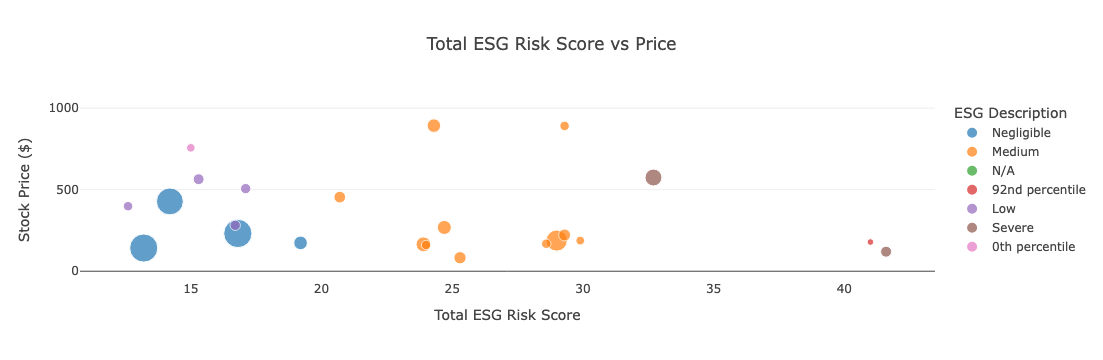

In [12]:
from IPython.display import Image
Image("bubble_plot.png")

The scatterplot that we derived from the dataframe checks to see if there is any relationship between the ESG and stock prices for the top 100 stocks with their respective ticker labels. We got a downward-sloping graph which suggested that stocks at higher prices often do have lower ESG ratings, however, stocks with lower prices have higher ESG ratings. But we could also observe inconsistencies in the relationship model which could also suggest that the result is not strictly linear in nature and the outputs may vary. This makes sense because different types of companies have different business models and are dealing in different businesses such as tech, industrial, healthcare, etc and it also heavily depends on the financials of the company. Because of these many varying factors which are different for each company there are bound to be some inconsistencies found in the plot.

### Beta (Volatility) Across ESG Levels

In [13]:
consolidated_df['Beta'] = pd.to_numeric(consolidated_df['Beta'], errors='coerce')

# Calculate average Beta for each ESG description
avg_beta_by_esg = consolidated_df.groupby('ESG Description')['Beta'].mean().reset_index()

# Create the bar chart
fig = px.bar(
    avg_beta_by_esg,
    x='ESG Description',
    y='Beta',
    color='ESG Description',
    title='Average Beta across ESG Risk Levels',
    labels={'Beta': 'Average Beta', 'ESG Description': 'ESG Risk Levels'}
)

fig.show()

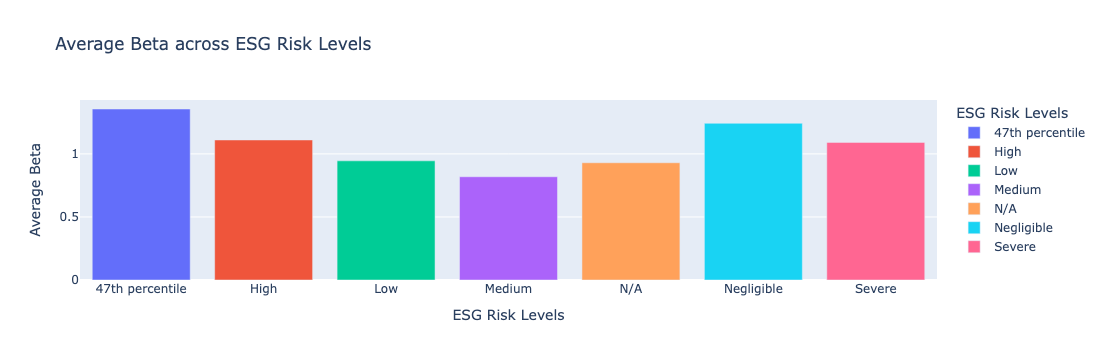

In [14]:
from IPython.display import Image
Image("bar_plot.png")

This bar chart illustrates the average beta across various ESG risk levels. Interestingly, stocks with a 'Negligible' ESG risk show a relatively higher average beta, suggesting that even companies with minimal ESG risks can exhibit significant volatility. Meanwhile, companies categorized under 'Medium' ESG risk display a lower average beta, indicating reduced stock volatility. Notably, both 'High' and 'Severe' ESG risk levels show a similar average beta to the 'Negligible' category, suggesting that a higher ESG risk does not always correlate with increased stock volatility.

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define the order of ESG risk levels
esg_order = ['Negligible', 'Low', 'Medium', 'High', 'Severe', 'N/A']

# Convert ESG Description to a categorical type with the specified order
consolidated_df['ESG Description'] = pd.Categorical(consolidated_df['ESG Description'], categories=esg_order, ordered=True)

# Calculate average price and beta across ESG risk levels
avg_values = consolidated_df.groupby('ESG Description').agg({'Price': 'mean', 'Beta': 'mean'}).reset_index()

# Create a subplot
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add the average price trace
fig.add_trace(
    go.Scatter(x=avg_values['ESG Description'], y=avg_values['Price'], name='Average Price', line=dict(color='blue')),
    secondary_y=False,)

# Add the average beta trace
fig.add_trace(
    go.Scatter(x=avg_values['ESG Description'], y=avg_values['Beta'], name='Average Beta', line=dict(color='orange')),
    secondary_y=True,)

fig.update_layout(
    title='Average Price and Beta Across ESG Risk Levels',
    xaxis_title='ESG Risk Level',
    yaxis_title='Average Price ($)',
    yaxis2_title='Average Beta')

fig.show()

In [16]:
#from IPython.display import Image
#Image("Dual_Axis_Line_Plot.png")

From observing this dual-axis line chart, which shows the average price and beta across ESG risk levels, companies with negligible and high ESG risk were found to have higher average prices on average, while medium risk companies tend to have the lowest prices. Beta is shown to be relatively stable across the risk categories, but companies with high and severe ESG risk tend to show a volatility that is slightly higher. From this graph, we cannot prove that there is a strict linear relationship, but companies with lower ESG risk tend to have more stable prices and beta levels.

## Data Usage and Remaining Issues

The collected data will be used to conduct a comparative analysis between companies with high ESG ratings and those with low or no ESG focus. I am planning that after we get the chance to dive into machine learning models like regression and classification, I can predict stock price volatility based on ESG ratings and assess whether companies with higher ESG scores enjoy a valuation premium. The general approach will involve predicting numerical values (such as stock price) and characterizing relationships between ESG scores and financial metrics like stock price and market capitalization. The project will ultimately help determine whether ESG practices provide companies with a market advantage and if they can protect investors during turbulent times.

## Some Ideas For Machine Learning Models:

### 1. Predicting Stock Volatility Based on ESG Scores
- We plan to use a regression model (e.g., Linear Regression, Random Forest Regressor) to predict a stock’s Beta (volatility) using ESG subcategories (Environmental, Social, Governance), the total ESG score, and other financial metrics like PE ratio, EPS, and market cap.
The objective is to see if specific ESG factors have significant predictive power over stock volatility.
- Features:
  - ESG sub-scores (Environmental, Social, Governance)
  - Total ESG score
  - PE Ratio
  - EPS (TTM)
Market Cap
- Target: Beta (stock volatility)

### 2. Classification of Stock Performance Using ESG Scores
- We are looking into using classification algorithms (e.g., KNN Classifier) to classify whether a stock performs well or poorly based on its ESG ratings and other factors. This will help us to gain further understanding of the future trend on whether high ESG scores can be associated with better stock performance (e.g., positive returns or lower volatility).
- Features:
  - ESG sub-scores
  - PE Ratio
  - Market Cap
- Target: Binary classification (e.g., 'High Return' or 'Low Return', based on a predefined threshold).

### 3. Analysis of Results
- confusion Matrix which can help understand the number of correctly and incorrectly classified samples.
- Classification Report: Provides metrics like precision, recall, F1-score, and accuracy.
- Feature Importance: Random Forests allow you to extract feature importance to see which ESG factors most influence stock performance.

### 4. Model Interpretation
- High Accuracy: Indicates a strong relationship between ESG factors and stock performance.
- Low Accuracy: Implies ESG factors alone may not be sufficient to predict stock returns or additional features may be needed.

### 5. Possible Enhancements
We should probably consider feature engineering: add more features like Return on Equity (ROE), Debt-to-Equity ratio, etc., to enhance prediction accuracy.